# Name : Agamdeep Singh, Roll no. : 102303261, Group : 3C21

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from scipy.stats import gaussian_kde


In [ ]:
data = pd.read_csv("data.csv", encoding="latin1")


no2_values = pd.to_numeric(data["no2"], errors="coerce")
no2_values = no2_values.dropna()
no2_values = no2_values[no2_values >= 0]

no2_values = no2_values.to_numpy()
print("Number of samples:", no2_values.shape[0])


/tmp/ipython-input-3030773780.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("data.csv", encoding="latin1")


Number of samples: 419509


In [ ]:
no2_values = (no2_values - no2_values.mean()) / no2_values.std()


In [ ]:
roll_number = 102317212

a_r = 0.5 * (roll_number % 7)
b_r = 0.3 * ((roll_number % 5) + 1)

print("a_r =", a_r)
print("b_r =", b_r)

z_values = no2_values + a_r * np.sin(b_r * no2_values)


a_r = 2.0
b_r = 0.8999999999999999


In [ ]:
z_real = torch.tensor(z_values.reshape(-1, 1), dtype=torch.float32)


In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)


In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)


In [ ]:
generator = Generator()
discriminator = Discriminator()

loss_fn = nn.BCELoss()

g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))


In [ ]:
epochs = 5000
batch_size = 128

generator.train()
discriminator.train()

for epoch in range(epochs):
    idx = np.random.randint(0, len(z_real), batch_size)
    real_samples = z_real[idx]

    real_labels = torch.ones(batch_size, 1)
    fake_labels = torch.zeros(batch_size, 1)


    noise = torch.randn(batch_size, 1)
    fake_samples = generator(noise)

    d_real = discriminator(real_samples)
    d_fake = discriminator(fake_samples.detach())

    d_loss = loss_fn(d_real, real_labels) + loss_fn(d_fake, fake_labels)

    d_optimizer.zero_grad()
    d_loss.backward()
    d_optimizer.step()


    noise = torch.randn(batch_size, 1)
    fake_samples = generator(noise)
    g_loss = loss_fn(discriminator(fake_samples), real_labels)

    g_optimizer.zero_grad()
    g_loss.backward()
    g_optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")


Epoch 0 | D Loss: 1.3077 | G Loss: 0.6351
Epoch 500 | D Loss: 1.4136 | G Loss: 0.6956
Epoch 1000 | D Loss: 1.3854 | G Loss: 0.6933
Epoch 1500 | D Loss: 1.3841 | G Loss: 0.6916
Epoch 2000 | D Loss: 1.3888 | G Loss: 0.6892
Epoch 2500 | D Loss: 1.3855 | G Loss: 0.6973
Epoch 3000 | D Loss: 1.3886 | G Loss: 0.6986
Epoch 3500 | D Loss: 1.3892 | G Loss: 0.6998
Epoch 4000 | D Loss: 1.3825 | G Loss: 0.6938
Epoch 4500 | D Loss: 1.3860 | G Loss: 0.6913


In [ ]:
generator.eval()

with torch.no_grad():
    noise = torch.randn(10000, 1)
    z_generated = generator(noise).numpy().flatten()


In [ ]:
kde_fake = gaussian_kde(z_generated)
kde_real = gaussian_kde(z_values)

z_axis = np.linspace(
    min(z_generated.min(), z_values.min()),
    max(z_generated.max(), z_values.max()),
    1000
)

pdf_fake = kde_fake(z_axis)
pdf_real = kde_real(z_axis)


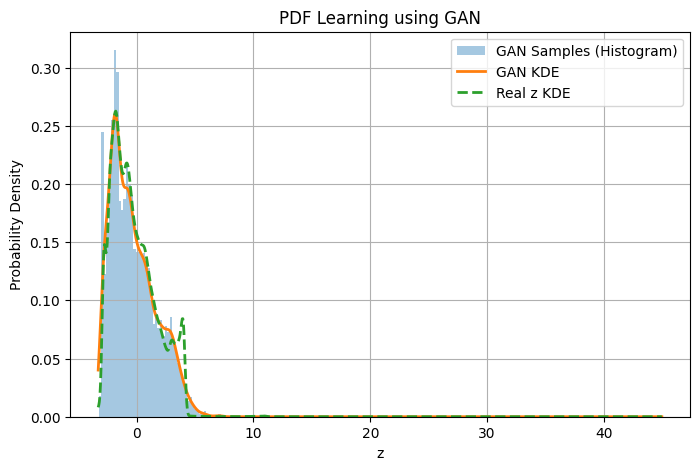

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(z_generated, bins=50, density=True, alpha=0.4, label="GAN Samples (Histogram)")
plt.plot(z_axis, pdf_fake, linewidth=2, label="GAN KDE")
plt.plot(z_axis, pdf_real, linestyle="--", linewidth=2, label="Real z KDE")

plt.xlabel("z")
plt.ylabel("Probability Density")
plt.title("PDF Learning using GAN")
plt.legend()
plt.grid(True)
plt.show()
